In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## VERİ

### Preprocessing

In [2]:
data = pd.read_csv("autism.csv")

PROFILES = sorted(data["profil"].unique())
N_SESSIONS, N_TRIALS, N_PROMPT = 12, 12, 4

X = data.drop(columns="profil").to_numpy(dtype="float32") / N_PROMPT
y = data["profil"].map({p: i for i, p in enumerate(PROFILES)}).to_numpy(dtype="int64")

N_FEATURES = X.shape[1]
N_CLASSES = len(PROFILES)
SEQ_LEN, SEQ_DIM = N_SESSIONS, N_TRIALS
IMG_SHAPE = (1, SEQ_LEN, SEQ_DIM)

VIEWS = pd.DataFrame(
    [["ANN", f"({N_FEATURES},)"],
     ["RNN", f"({SEQ_LEN}, {SEQ_DIM})"],
     ["CNN", f"({IMG_SHAPE[0]}, {IMG_SHAPE[1]}, {IMG_SHAPE[2]})"],
     ["Transformer", f"({SEQ_LEN}, {SEQ_DIM})"]],
    columns=["Architecture", "Input"],
)
VIEWS

,Architecture,Input
0,ANN,"(144,)"
1,RNN,"(12, 12)"
2,CNN,"(1, 12, 12)"
3,Transformer,"(12, 12)"


### Split

In [3]:
X_pool, X_prod, y_pool, y_prod = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)

X_train, X_traindev, y_train, y_traindev = train_test_split(
    X_pool, y_pool, test_size=0.20, stratify=y_pool, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_prod, y_prod, test_size=0.50, stratify=y_prod, random_state=SEED)

SPLITS = {
    "Train": (X_train, y_train),
    "Train-Dev": (X_traindev, y_traindev),
    "Validation": (X_val, y_val),
    "Test": (X_test, y_test),
}

pd.DataFrame({name: [len(ys)] for name, (Xs, ys) in SPLITS.items()}, index=["n"])

,Train,Train-Dev,Validation,Test
n,1008,252,270,270


## MODEL

In [4]:
EPOCHS, PATIENCE, N_TRIALS = 40, 8, 6
ARCHITECTURES = ["ANN", "RNN", "CNN", "Transformer"]
MODELS, TUNED, HP, SPACE, BEST_HP, TRIALS = {}, {}, {}, {}, {}, {}

LOSS = nn.CrossEntropyLoss()

OPTIMIZER = {
    "adam": lambda p, hp: torch.optim.Adam(p, lr=hp["lr"], weight_decay=hp["l2"]),
    "sgd_momentum": lambda p, hp: torch.optim.SGD(p, lr=hp["lr"], momentum=0.9, weight_decay=hp["l2"]),
    "adamw": lambda p, hp: torch.optim.AdamW(p, lr=hp["lr"], weight_decay=hp["l2"]),
    "adagrad": lambda p, hp: torch.optim.Adagrad(p, lr=hp["lr"], weight_decay=hp["l2"]),
}


def make_scheduler(optimizer, hp):
    if hp["scheduler"] == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, hp["epochs"] // 3), gamma=0.5)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, hp["epochs"] - hp["warmup"]))
    if hp["warmup"] == 0:
        return cosine
    warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=hp["warmup"])
    return torch.optim.lr_scheduler.SequentialLR(optimizer, [warmup, cosine], milestones=[hp["warmup"]])


def make_loader(Xs, ys, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(Xs), torch.from_numpy(ys))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


@torch.no_grad()
def predict_proba(model, Xs, batch_size=512):
    model.eval()
    Xs = np.asarray(Xs, dtype="float32")
    out = []
    for i in range(0, len(Xs), batch_size):
        xb = torch.from_numpy(Xs[i:i + batch_size]).to(DEVICE)
        out.append(torch.softmax(model(xb), dim=1).cpu().numpy())
    return np.vstack(out)


def predict(model, Xs):
    return predict_proba(model, Xs).argmax(axis=1)


def error(model, Xs, ys):
    return float((predict(model, Xs) != ys).mean())


@torch.no_grad()
def loss_of(model, Xs, ys):
    model.eval()
    xb, yb = torch.from_numpy(Xs).to(DEVICE), torch.from_numpy(ys).to(DEVICE)
    return float(LOSS(model(xb), yb))


def train_model(architecture, hp):
    torch.manual_seed(SEED)
    model = architecture(hp).to(DEVICE)
    optimizer = OPTIMIZER[hp["optimizer"]](model.parameters(), hp)
    scheduler = make_scheduler(optimizer, hp)
    loader = make_loader(X_train, y_train, hp["batch_size"], hp["shuffle"])
    best_loss, best_state, wait = np.inf, None, 0
    for _ in range(hp["epochs"]):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = LOSS(model(xb), yb)
            if hp["l1"] > 0:
                loss = loss + hp["l1"] * sum(p.abs().sum() for p in model.parameters())
            loss.backward()
            optimizer.step()
        scheduler.step()
        current = loss_of(model, X_val, y_val)
        if current < best_loss - 1e-4:
            best_loss, wait = current, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= hp["patience"]:
                break
    model.load_state_dict(best_state)
    return model


def split_errors(model):
    return {f"{name} E": error(model, Xs, ys) for name, (Xs, ys) in SPLITS.items()}


def random_search(architecture, space, n_trials=N_TRIALS):
    rng = np.random.default_rng(SEED)
    trials, best_model, best_hp, best_error = [], None, None, np.inf
    for _ in range(n_trials):
        hp = {k: v[int(rng.integers(len(v)))] if isinstance(v, list) else v for k, v in space.items()}
        model = train_model(architecture, hp)
        val_error = error(model, X_val, y_val)
        trials.append({**{k: hp[k] for k in space if isinstance(space[k], list)},
                       "Validation E": val_error})
        if val_error < best_error:
            best_model, best_hp, best_error = model, hp, val_error
    return best_model, best_hp, pd.DataFrame(trials).sort_values("Validation E").reset_index(drop=True)


def stages(name):
    return [("Training", MODELS[name]), ("Tuning", TUNED[name])]

### ANN

#### Training

In [5]:
class ANN(nn.Module):
    def __init__(self, hp):
        super().__init__()
        layers, d_in = [], N_FEATURES
        for _ in range(hp["n_layers"]):
            layers += [nn.Linear(d_in, hp["hidden_dim"]),
                       nn.BatchNorm1d(hp["hidden_dim"]),
                       nn.ReLU(),
                       nn.Dropout(hp["dropout"])]
            d_in = hp["hidden_dim"]
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(d_in, N_CLASSES)

    def forward(self, x):
        z = x.view(-1, N_FEATURES)
        return self.head(self.body(z))


HP["ANN"] = dict(n_layers=2, hidden_dim=128, dropout=0.2,
                 optimizer="adam", lr=1e-3, l1=0.0, l2=1e-4,
                 batch_size=64, epochs=EPOCHS, shuffle=True,
                 scheduler="cosine", warmup=0, patience=PATIENCE)

MODELS["ANN"] = train_model(ANN, HP["ANN"])
pd.Series(split_errors(MODELS["ANN"]), name="ANN").to_frame().T

,Train E,Train-Dev E,Validation E,Test E
ANN,0.002976,0.071429,0.055556,0.07037


#### Tuning

In [6]:
SPACE["ANN"] = dict(n_layers=[1, 2, 3], hidden_dim=[64, 128, 256], dropout=[0.0, 0.2, 0.4],
                    optimizer=["adam"], lr=[3e-4, 1e-3, 3e-3], l1=[0.0, 1e-5], l2=[0.0, 1e-4, 1e-3],
                    batch_size=[32, 64, 128], epochs=EPOCHS, shuffle=True,
                    scheduler=["cosine", "step"], warmup=[0, 5], patience=PATIENCE)

TUNED["ANN"], BEST_HP["ANN"], TRIALS["ANN"] = random_search(ANN, SPACE["ANN"])
TRIALS["ANN"]

,n_layers,hidden_dim,dropout,optimizer,lr,l1,l2,batch_size,scheduler,warmup,Validation E
0,3,128,0.2,adam,0.001,0.00000,0.000,64,step,0,0.055556
1,3,128,0.2,adam,0.001,0.00000,0.001,128,step,0,0.055556
2,3,256,0.0,adam,0.001,0.00000,0.001,128,cosine,0,0.062963
3,3,128,0.4,adam,0.003,0.00001,0.001,32,cosine,0,0.070370
4,1,128,0.4,adam,0.003,0.00001,0.001,128,step,0,0.085185
5,1,256,0.2,adam,0.001,0.00000,0.001,32,step,0,0.092593


### RNN

#### Training

In [7]:
class RNN(nn.Module):
    def __init__(self, hp):
        super().__init__()
        self.rnn = nn.RNN(SEQ_DIM, hp["hidden_dim"], num_layers=hp["n_layers"],
                          nonlinearity="tanh", batch_first=True,
                          dropout=hp["dropout"] if hp["n_layers"] > 1 else 0.0)
        self.body = nn.Sequential(nn.LayerNorm(hp["hidden_dim"]), nn.Dropout(hp["dropout"]))
        self.head = nn.Linear(hp["hidden_dim"], N_CLASSES)

    def forward(self, x):
        z = x.view(-1, SEQ_LEN, SEQ_DIM)
        h, _ = self.rnn(z)
        return self.head(self.body(h[:, -1]))


HP["RNN"] = dict(n_layers=1, hidden_dim=128, dropout=0.2,
                 optimizer="adam", lr=1e-3, l1=0.0, l2=1e-4,
                 batch_size=64, epochs=EPOCHS, shuffle=True,
                 scheduler="cosine", warmup=0, patience=PATIENCE)

MODELS["RNN"] = train_model(RNN, HP["RNN"])
pd.Series(split_errors(MODELS["RNN"]), name="RNN").to_frame().T

,Train E,Train-Dev E,Validation E,Test E
RNN,0.019841,0.071429,0.051852,0.062963


#### Tuning

In [8]:
SPACE["RNN"] = dict(n_layers=[1, 2], hidden_dim=[64, 128, 256], dropout=[0.0, 0.2, 0.4],
                    optimizer=["adam"], lr=[3e-4, 1e-3, 3e-3], l1=[0.0, 1e-5], l2=[0.0, 1e-4, 1e-3],
                    batch_size=[32, 64, 128], epochs=EPOCHS, shuffle=True,
                    scheduler=["cosine", "step"], warmup=[0, 5], patience=PATIENCE)

TUNED["RNN"], BEST_HP["RNN"], TRIALS["RNN"] = random_search(RNN, SPACE["RNN"])
TRIALS["RNN"]

,n_layers,hidden_dim,dropout,optimizer,lr,l1,l2,batch_size,scheduler,warmup,Validation E
0,2,128,0.4,adam,0.003,0.00001,0.001,32,cosine,0,0.033333
1,2,128,0.2,adam,0.001,0.00000,0.000,64,step,0,0.037037
2,2,128,0.2,adam,0.001,0.00000,0.001,128,step,0,0.048148
3,2,256,0.0,adam,0.001,0.00000,0.001,128,cosine,0,0.055556
4,1,128,0.4,adam,0.003,0.00001,0.001,128,step,0,0.066667
5,1,256,0.2,adam,0.001,0.00000,0.001,32,step,0,0.070370


### CNN

#### Training

In [9]:
class CNN(nn.Module):
    def __init__(self, hp):
        super().__init__()
        layers, c_in = [], IMG_SHAPE[0]
        for _ in range(hp["n_layers"]):
            layers += [nn.Conv2d(c_in, hp["n_filters"], hp["kernel_size"], padding=hp["kernel_size"] // 2),
                       nn.BatchNorm2d(hp["n_filters"]),
                       nn.ReLU()]
            c_in = hp["n_filters"]
        self.body = nn.Sequential(*layers)
        self.pool = nn.Sequential(nn.AdaptiveMaxPool2d(2), nn.Flatten(), nn.Dropout(hp["dropout"]))
        self.head = nn.Linear(hp["n_filters"] * 4, N_CLASSES)

    def forward(self, x):
        z = x.view(-1, *IMG_SHAPE)
        return self.head(self.pool(self.body(z)))


HP["CNN"] = dict(n_layers=2, n_filters=32, kernel_size=3, dropout=0.2,
                 optimizer="sgd_momentum", lr=5e-2, l1=0.0, l2=1e-4,
                 batch_size=64, epochs=EPOCHS, shuffle=True,
                 scheduler="cosine", warmup=0, patience=PATIENCE)

MODELS["CNN"] = train_model(CNN, HP["CNN"])
pd.Series(split_errors(MODELS["CNN"]), name="CNN").to_frame().T

,Train E,Train-Dev E,Validation E,Test E
CNN,0.021825,0.075397,0.040741,0.074074


#### Tuning

In [10]:
SPACE["CNN"] = dict(n_layers=[1, 2, 3], n_filters=[16, 32, 64], kernel_size=[3, 5], dropout=[0.0, 0.2, 0.4],
                    optimizer=["sgd_momentum"], lr=[1e-2, 5e-2, 1e-1], l1=[0.0, 1e-5], l2=[0.0, 1e-4, 1e-3],
                    batch_size=[32, 64, 128], epochs=EPOCHS, shuffle=True,
                    scheduler=["cosine", "step"], warmup=[0, 5], patience=PATIENCE)

TUNED["CNN"], BEST_HP["CNN"], TRIALS["CNN"] = random_search(CNN, SPACE["CNN"])
TRIALS["CNN"]

,n_layers,n_filters,kernel_size,dropout,optimizer,lr,l1,l2,batch_size,scheduler,warmup,Validation E
0,3,16,3,0.2,sgd_momentum,0.05,0.00000,0.0001,32,step,5,0.022222
1,2,64,5,0.4,sgd_momentum,0.10,0.00001,0.0001,32,step,0,0.025926
2,1,64,5,0.2,sgd_momentum,0.05,0.00001,0.0000,128,cosine,0,0.040741
3,2,16,3,0.2,sgd_momentum,0.10,0.00000,0.0010,128,cosine,5,0.044444
4,2,32,3,0.4,sgd_momentum,0.10,0.00001,0.0001,128,step,0,0.051852
5,1,64,5,0.2,sgd_momentum,0.01,0.00001,0.0001,128,step,5,0.062963


### Transformer

#### Training

In [11]:
class Attention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads, self.d_k = n_heads, d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        b, t, _ = x.shape
        q, k, v = [w(x).view(b, t, self.n_heads, self.d_k).transpose(1, 2)
                   for w in (self.w_q, self.w_k, self.w_v)]
        attention = torch.softmax(q @ k.transpose(-2, -1) / self.d_k ** 0.5, dim=-1)
        z = (attention @ v).transpose(1, 2).reshape(b, t, self.n_heads * self.d_k)
        return self.w_o(z)


class Block(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, dropout):
        super().__init__()
        self.attention = Attention(d_model, n_heads)
        self.feed_forward = nn.Sequential(nn.Linear(d_model, ff_dim), nn.GELU(), nn.Linear(ff_dim, d_model))
        self.norm_1, self.norm_2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.norm_1(x + self.drop(self.attention(x)))
        return self.norm_2(x + self.drop(self.feed_forward(x)))


class Transformer(nn.Module):
    def __init__(self, hp):
        super().__init__()
        self.embedding = nn.Linear(SEQ_DIM, hp["d_model"])
        self.position = nn.Parameter(torch.zeros(1, SEQ_LEN, hp["d_model"]))
        self.body = nn.Sequential(*[Block(hp["d_model"], hp["n_heads"], hp["ff_dim"], hp["dropout"])
                                    for _ in range(hp["n_layers"])])
        self.drop = nn.Dropout(hp["dropout"])
        self.head = nn.Linear(hp["d_model"], N_CLASSES)

    def forward(self, x):
        z = self.embedding(x.view(-1, SEQ_LEN, SEQ_DIM)) + self.position
        return self.head(self.drop(self.body(z).mean(dim=1)))


HP["Transformer"] = dict(n_layers=2, d_model=64, n_heads=4, ff_dim=128, dropout=0.1,
                         optimizer="adamw", lr=1e-3, l1=0.0, l2=1e-2,
                         batch_size=64, epochs=EPOCHS, shuffle=True,
                         scheduler="cosine", warmup=5, patience=PATIENCE)

MODELS["Transformer"] = train_model(Transformer, HP["Transformer"])
pd.Series(split_errors(MODELS["Transformer"]), name="Transformer").to_frame().T

,Train E,Train-Dev E,Validation E,Test E
Transformer,0.017857,0.063492,0.033333,0.07037


#### Tuning

In [12]:
SPACE["Transformer"] = dict(n_layers=[1, 2, 3], d_model=[32, 64], n_heads=[2, 4], ff_dim=[64, 128],
                            dropout=[0.0, 0.1, 0.3], optimizer=["adamw"], lr=[3e-4, 1e-3, 3e-3],
                            l1=[0.0, 1e-5], l2=[1e-3, 1e-2, 1e-1], batch_size=[32, 64, 128],
                            epochs=EPOCHS, shuffle=True, scheduler=["cosine", "step"],
                            warmup=[0, 5], patience=PATIENCE)

TUNED["Transformer"], BEST_HP["Transformer"], TRIALS["Transformer"] = random_search(Transformer, SPACE["Transformer"])
TRIALS["Transformer"]

,n_layers,d_model,n_heads,ff_dim,dropout,optimizer,lr,l1,l2,batch_size,scheduler,warmup,Validation E
0,1,64,4,64,0.1,adamw,0.0030,0.00000,0.100,32,cosine,5,0.048148
1,3,64,4,128,0.3,adamw,0.0010,0.00000,0.100,64,step,0,0.051852
2,1,64,4,128,0.1,adamw,0.0030,0.00001,0.010,64,cosine,0,0.062963
3,1,64,2,128,0.3,adamw,0.0030,0.00001,0.001,64,cosine,0,0.066667
4,1,64,2,128,0.3,adamw,0.0030,0.00001,0.010,128,cosine,0,0.070370
5,2,64,2,128,0.3,adamw,0.0003,0.00001,0.001,128,step,0,0.174074


## DEĞERLENDİRME

In [13]:
def confusion_parts(cm):
    TP = np.diag(cm).astype(float)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - TP - FP - FN
    return TP, TN, FP, FN


def classification_metrics(model, Xs, ys):
    cm = confusion_matrix(ys, predict(model, Xs), labels=range(N_CLASSES))
    TP, TN, FP, FN = confusion_parts(cm)
    accuracy = TP.sum() / cm.sum()
    precision = np.divide(TP, TP + FP, out=np.zeros_like(TP), where=(TP + FP) > 0)
    recall = np.divide(TP, TP + FN, out=np.zeros_like(TP), where=(TP + FN) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall,
                   out=np.zeros_like(TP), where=(precision + recall) > 0)
    return {"Accuracy": accuracy, "Precision": precision.mean(),
            "Recall": recall.mean(), "F1": f1.mean()}


def diagnose(errors, high=0.10, gap=0.05, leak=0.005):
    train, train_dev = errors["Train E"], errors["Train-Dev E"]
    validation, test = errors["Validation E"], errors["Test E"]
    if max(train, train_dev, validation, test) <= leak:
        return "Data Leakage"
    if min(train, train_dev, validation, test) >= high:
        return "Underfitting"
    if train_dev - train >= gap:
        return "Overfitting"
    if validation - train_dev >= gap:
        return "Data Mismatch"
    return "Good Generalization"


def evaluate(name):
    return pd.DataFrame({stage: classification_metrics(model, X_test, y_test)
                         for stage, model in stages(name)}).T.round(4)


def error_table(name):
    rows = {}
    for stage, model in stages(name):
        errors = split_errors(model)
        rows[stage] = {**{k: round(v, 4) for k, v in errors.items()}, "Diagnosis": diagnose(errors)}
    return pd.DataFrame(rows).T


def plot_confusion(name):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, (stage, model) in zip(axes, stages(name)):
        cm = confusion_matrix(y_test, predict(model, X_test), labels=range(N_CLASSES))
        ax.imshow(cm)
        ax.set_title(f"{name} | {stage}")
        ax.set_xlabel("y_hat")
        ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()

### ANN

#### Classification Prediction

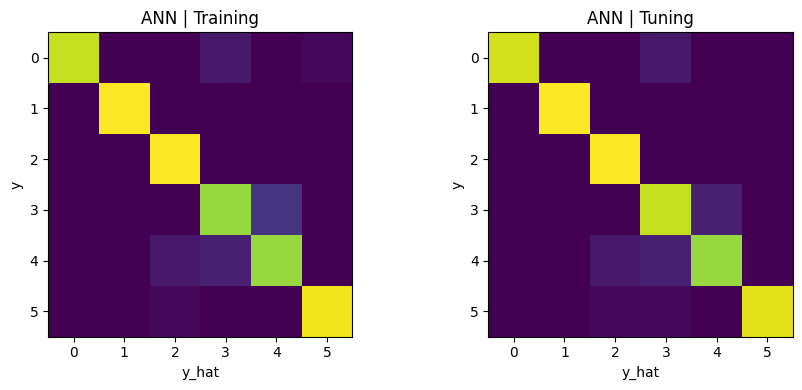

,Accuracy,Precision,Recall,F1
Training,0.9296,0.9308,0.9296,0.9296
Tuning,0.9407,0.9433,0.9407,0.9410


In [14]:
plot_confusion("ANN")
evaluate("ANN")

#### Errors

In [15]:
error_table("ANN")

,Train E,Train-Dev E,Validation E,Test E,Diagnosis
Training,0.003,0.0714,0.0556,0.0704,Overfitting
Tuning,0.0,0.0595,0.0556,0.0593,Overfitting


### RNN

#### Classification Prediction

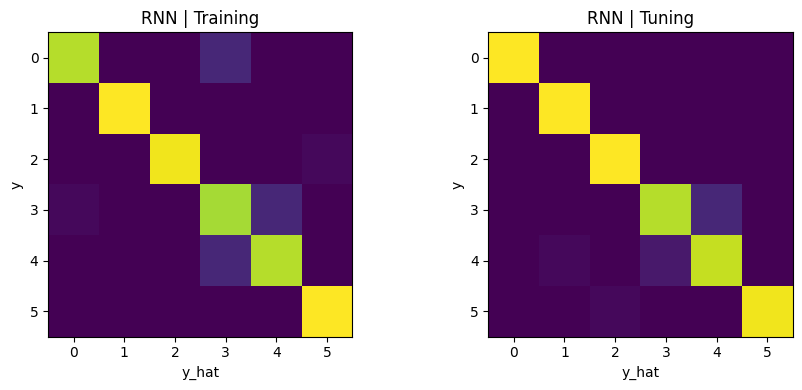

,Accuracy,Precision,Recall,F1
Training,0.937,0.9398,0.937,0.9378
Tuning,0.963,0.9630,0.963,0.9628


In [16]:
plot_confusion("RNN")
evaluate("RNN")

#### Errors

In [17]:
error_table("RNN")

,Train E,Train-Dev E,Validation E,Test E,Diagnosis
Training,0.0198,0.0714,0.0519,0.063,Overfitting
Tuning,0.0149,0.0595,0.0333,0.037,Good Generalization


### CNN

#### Classification Prediction

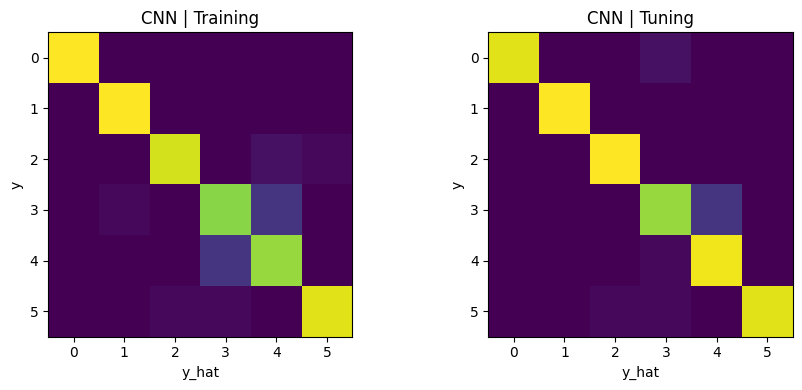

,Accuracy,Precision,Recall,F1
Training,0.9259,0.9272,0.9259,0.9264
Tuning,0.9556,0.9576,0.9556,0.9556


In [18]:
plot_confusion("CNN")
evaluate("CNN")

#### Errors

In [19]:
error_table("CNN")

,Train E,Train-Dev E,Validation E,Test E,Diagnosis
Training,0.0218,0.0754,0.0407,0.0741,Overfitting
Tuning,0.005,0.0595,0.0222,0.0444,Overfitting


### Transformer

#### Classification Prediction

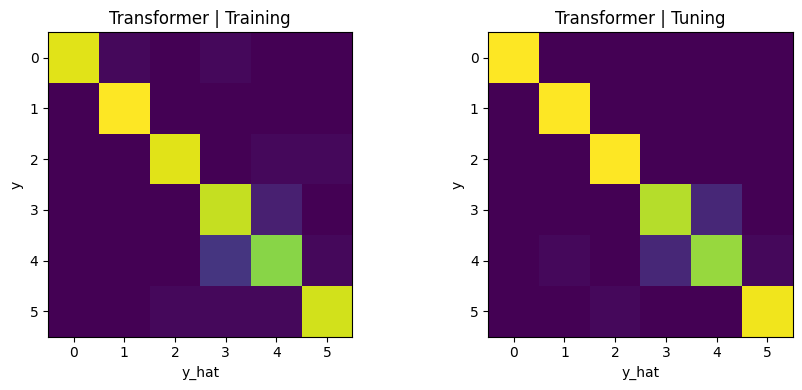

,Accuracy,Precision,Recall,F1
Training,0.9296,0.9318,0.9296,0.9301
Tuning,0.9519,0.9512,0.9519,0.9514


In [20]:
plot_confusion("Transformer")
evaluate("Transformer")

#### Errors

In [21]:
error_table("Transformer")

,Train E,Train-Dev E,Validation E,Test E,Diagnosis
Training,0.0179,0.0635,0.0333,0.0704,Good Generalization
Tuning,0.0228,0.0675,0.0481,0.0481,Good Generalization


## AÇIKLANABİLİRLİK

In [22]:
N_EXPLAIN, N_SAMPLES = 4, 400
BACKGROUND = shap.kmeans(X_train, 20)
X_EXPLAIN = X_test[:N_EXPLAIN]
PHI_0, PHI = {}, {}


def shap_explain(name):
    phi_0, phi = {}, {}
    for stage, model in stages(name):
        explainer = shap.KernelExplainer(lambda x: predict_proba(model, x), BACKGROUND)
        values = np.array(explainer.shap_values(X_EXPLAIN, nsamples=N_SAMPLES, l1_reg=0, silent=True))
        if values.shape[0] == N_CLASSES:
            values = np.transpose(values, (1, 2, 0))
        phi_0[stage], phi[stage] = np.array(explainer.expected_value), values
    return phi_0, phi


def additivity(name):
    rows = []
    for stage, model in stages(name):
        proba = predict_proba(model, X_EXPLAIN)
        phi_0, phi = PHI_0[name][stage], PHI[name][stage]
        for i, c in enumerate(proba.argmax(axis=1)):
            rows.append({"Stage": stage, "c_hat": int(c), "phi_0": phi_0[c],
                         "sum_phi_i": phi[i, :, c].sum(),
                         "phi_0 + sum_phi_i": phi_0[c] + phi[i, :, c].sum(),
                         "f(x)": proba[i, c]})
    return pd.DataFrame(rows).round(4)


def plot_attribution(name):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, (stage, model) in zip(axes, stages(name)):
        ax.imshow(np.abs(PHI[name][stage]).mean(axis=(0, 2)).reshape(SEQ_LEN, SEQ_DIM))
        ax.set_title(f"{name} | {stage}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### ANN

#### SHAP

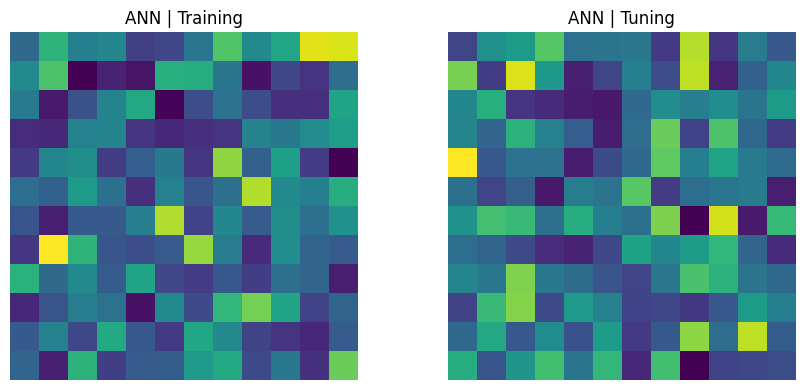

,Stage,c_hat,phi_0,sum_phi_i,phi_0 + sum_phi_i,f(x)
0,Training,2,0.1691,0.8231,0.9922,0.9922
1,Training,1,0.1627,0.8357,0.9985,0.9985
2,Training,3,0.1690,0.8199,0.9889,0.9889
3,Training,5,0.1611,0.7712,0.9324,0.9324
4,Tuning,2,0.1684,0.8290,0.9974,0.9974
5,Tuning,1,0.1622,0.8354,0.9975,0.9975
6,Tuning,3,0.1682,0.8283,0.9965,0.9965
7,Tuning,5,0.1531,0.8174,0.9705,0.9705


In [23]:
PHI_0["ANN"], PHI["ANN"] = shap_explain("ANN")
plot_attribution("ANN")
additivity("ANN")

### RNN

#### SHAP

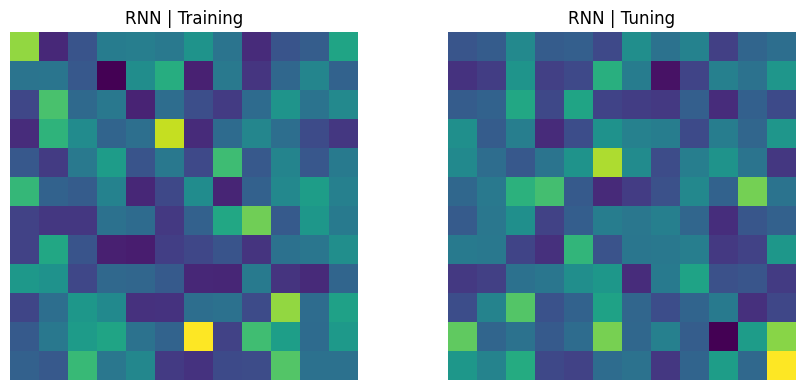

,Stage,c_hat,phi_0,sum_phi_i,phi_0 + sum_phi_i,f(x)
0,Training,2,0.1675,0.8249,0.9925,0.9925
1,Training,1,0.1627,0.8359,0.9986,0.9986
2,Training,3,0.1535,0.8044,0.9579,0.9579
3,Training,5,0.1682,0.8024,0.9706,0.9706
4,Tuning,2,0.1675,0.8292,0.9967,0.9967
5,Tuning,1,0.1617,0.8372,0.9989,0.9989
6,Tuning,3,0.1488,0.8423,0.9910,0.9910
7,Tuning,5,0.1673,0.8270,0.9943,0.9943


In [24]:
PHI_0["RNN"], PHI["RNN"] = shap_explain("RNN")
plot_attribution("RNN")
additivity("RNN")

### CNN

#### SHAP

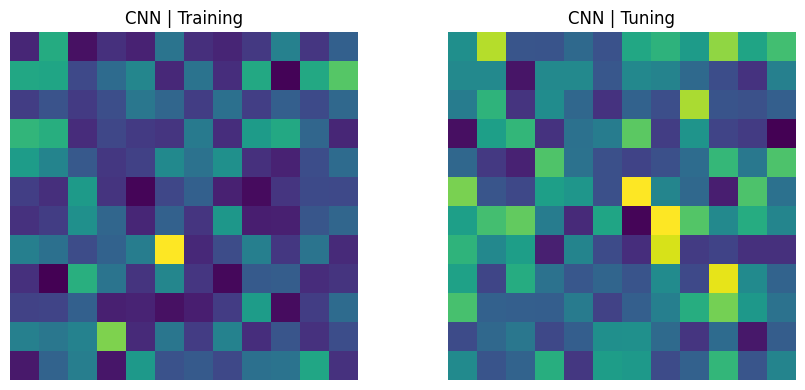

,Stage,c_hat,phi_0,sum_phi_i,phi_0 + sum_phi_i,f(x)
0,Training,2,0.1685,0.8303,0.9988,0.9988
1,Training,1,0.1623,0.8377,1.0000,1.0000
2,Training,3,0.2048,0.7847,0.9895,0.9895
3,Training,5,0.1573,0.8297,0.9870,0.9870
4,Tuning,2,0.1678,0.8320,0.9998,0.9998
5,Tuning,1,0.1623,0.8377,1.0000,1.0000
6,Tuning,3,0.2608,0.7205,0.9814,0.9814
7,Tuning,5,0.1603,0.8397,1.0000,1.0000


In [25]:
PHI_0["CNN"], PHI["CNN"] = shap_explain("CNN")
plot_attribution("CNN")
additivity("CNN")

### Transformer

#### SHAP

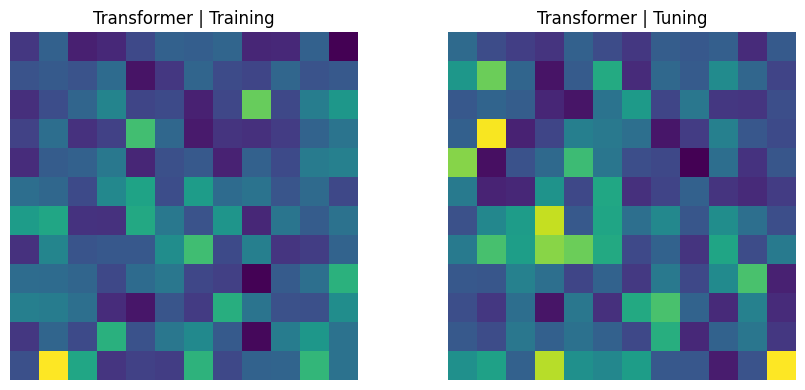

,Stage,c_hat,phi_0,sum_phi_i,phi_0 + sum_phi_i,f(x)
0,Training,2,0.1682,0.8297,0.9980,0.9980
1,Training,1,0.1620,0.8222,0.9842,0.9842
2,Training,3,0.1700,0.8275,0.9975,0.9975
3,Training,5,0.1524,0.8403,0.9926,0.9926
4,Tuning,2,0.1675,0.8288,0.9963,0.9963
5,Tuning,1,0.1617,0.8356,0.9974,0.9974
6,Tuning,3,0.1777,0.8195,0.9973,0.9973
7,Tuning,5,0.1537,0.8329,0.9865,0.9865


In [26]:
PHI_0["Transformer"], PHI["Transformer"] = shap_explain("Transformer")
plot_attribution("Transformer")
additivity("Transformer")